# Mixing below a confluence

#### This notebook analyses the mixing from CT-5 and CT-6 parents to the downstream children, CT-4 -> CT-10 -> CT-11 -> CT-8.2
To better understand this downstream mixing analyses of both detrital zircon data and Be-10 data are used

### Understanding downstream mixing vs zircon distribution

In [4]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import geopandas as gpd
import rasterio
import csv
from rasterio.plot import show
from geopy.distance import geodesic
from shapely.geometry import LineString, Point

In [5]:
# Load your Excel file into a DataFrame 
df = pd.read_excel('/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/MataquitoSampleData.xlsx') 

# Print the DataFrame to display its contents
print(df)

    Sample_ID Sample_Type   Latitude  Longitude  Source_Area  Elevation  \
0        CT-1  river sand -35.261470 -71.042330     1385.185      550.0   
1        CT-2  river sand -35.038830 -72.067050     5760.128       11.0   
2        CT-3  river sand -35.100380 -71.946720      189.205       18.0   
3        CT-4  river sand -35.027690 -71.487020     4706.717      111.0   
4        CT-5  river sand -34.962640 -71.359940     1495.897      155.0   
5        CT-6  river sand -34.984880 -71.342700     2573.245      158.0   
6        CT-7  river sand -35.003550 -70.827530     1207.810      631.0   
7        CT-8  river sand -35.092222 -71.647745     4950.395       78.0   
8        CT-9  river sand -35.046389 -72.101111     6189.716        9.0   
9       CT-10  river sand -35.049444 -71.550000     4864.942      102.0   
10      CT-11  river sand -35.064167 -71.610278     4913.334       89.0   
11        NaN         NaN        NaN        NaN          NaN        NaN   
12   CT-Ter-2        sand

Generated 11 flowlines
Using confluence coordinates: (282071, 6126393)
CT-5 (upstream): 3.92 km to confluence
CT-6 (upstream): 5.95 km to confluence
CT-4 (downstream): 14.65 km from confluence
CT-10 (approx): 16.40 km from confluence
CT-11 (approx): 21.82 km from confluence
CT-8 (approx): 26.69 km from confluence


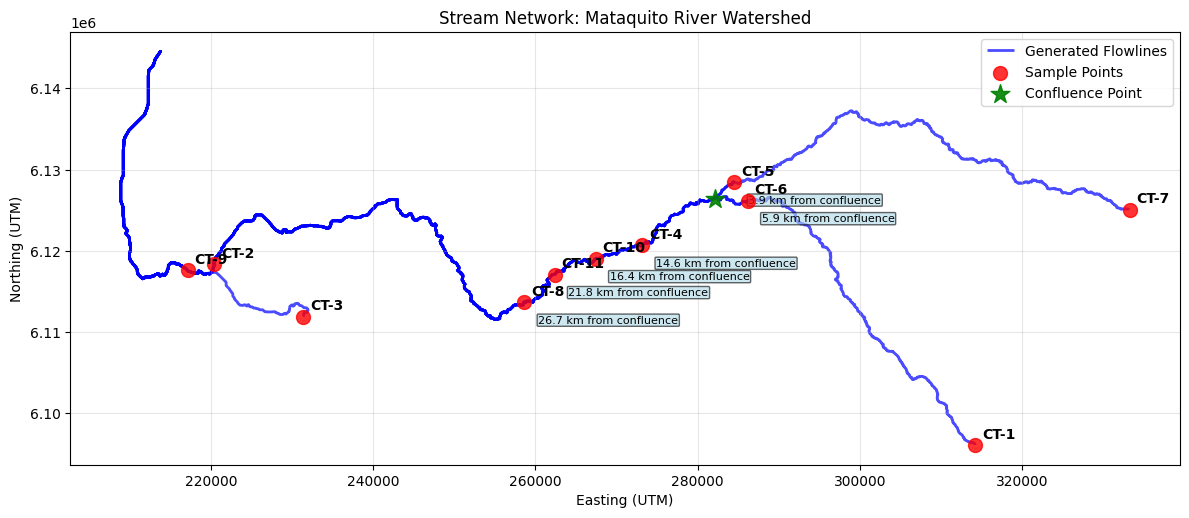

/var/folders/q2/0xd1lglj6lzdx_7wr72bt7t00000gp/T/ipykernel_49097/501517529.py:368: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  flowlines_gdf.to_file("Shapefiles/corrected_flowlines.shp")
/Users/Glong1/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'sample_name' to 'sample_nam'
  ogr_write(


In [6]:
def create_flowlines_from_raster(flow_direction_path, area_path, samples_gdf, min_drainage_area=50):
    """
    Create flowlines from raster data for each sample point.
    """
    
    # Load the raster files
    with rasterio.open(flow_direction_path) as fd_src:
        flow_direction = fd_src.read(1)
        transform = fd_src.transform
        
    with rasterio.open(area_path) as area_src:
        drainage_area = area_src.read(1)
    
    # Flow direction codes (standard D8 format)
    flow_directions = {
        1: (0, 1),    # East
        2: (1, 1),    # Southeast  
        4: (1, 0),    # South
        8: (1, -1),   # Southwest
        16: (0, -1),  # West
        32: (-1, -1), # Northwest
        64: (-1, 0),  # North
        128: (-1, 1)  # Northeast
    }
    
    def coords_to_pixel(x, y, transform):
        """Convert real world coordinates to pixel coordinates"""
        col, row = ~transform * (x, y)
        return int(row), int(col)
    
    def pixel_to_coords(row, col, transform):
        """Convert pixel coordinates to real world coordinates"""
        x, y = transform * (col, row)
        return x, y
    
    def trace_downstream(start_row, start_col, max_length=10000):
        """Trace downstream from a starting point"""
        path = []
        current_row, current_col = start_row, start_col
        
        for _ in range(max_length):
            # Check bounds
            if (current_row < 0 or current_row >= flow_direction.shape[0] or 
                current_col < 0 or current_col >= flow_direction.shape[1]):
                break
            
            # Get current position coordinates
            x, y = pixel_to_coords(current_row, current_col, transform)
            path.append((x, y))
            
            # Get flow direction value
            fd_value = flow_direction[current_row, current_col]
            
            # Check if we've reached a sink or invalid cell
            if fd_value == 0 or fd_value not in flow_directions:
                break
            
            # Check drainage area threshold
            if drainage_area[current_row, current_col] < min_drainage_area:
                break
            
            # Move to next cell
            row_offset, col_offset = flow_directions[fd_value]
            current_row += row_offset
            current_col += col_offset
        
        return path
    
    # Create flowlines for each sample
    flowlines = []
    
    for idx, sample in samples_gdf.iterrows():
        sample_name = sample['Name']
        sample_point = sample.geometry
        
        # Convert to pixel coordinates
        start_row, start_col = coords_to_pixel(sample_point.x, sample_point.y, transform)
        
        # Trace downstream
        path = trace_downstream(start_row, start_col)
        
        if len(path) > 1:
            line = LineString(path)
            flowlines.append({
                'sample_name': sample_name,
                'geometry': line,
                'length_km': line.length / 1000
            })
            #print(f"  Created flowline with {len(path)} points, length: {line.length/1000:.2f} km")
        else:
            print(f"  Warning: Could not create flowline for {sample_name}")
    
    # Convert to GeoDataFrame
    if flowlines:
        flowlines_gdf = gpd.GeoDataFrame(flowlines, crs=samples_gdf.crs)
        return flowlines_gdf
    else:
        print("Warning: No flowlines created")
        return gpd.GeoDataFrame(columns=['sample_name', 'geometry', 'length_km'], crs=samples_gdf.crs)


def calculate_stream_distances_from_confluence_fixed(samples_gdf, flowlines_gdf, 
                                                   target_samples=['CT-4', 'CT-10', 'CT-11', 'CT-8'],
                                                   tributary_samples=['CT-5', 'CT-6'],
                                                   confluence_coords=(282071, 6126393)):
    """
    Calculate stream distances using the network of flowlines.
    Confluence is a fixed point that is taken for a QGIS point (which is the confluence point on the flowline)
    """
    
    distances = {}
    confluence_point = Point(confluence_coords[0], confluence_coords[1])
    
    print(f"Using confluence coordinates: {confluence_coords}")
    
    # UPSTREAM SAMPLES (CT-5, CT-6) - confluence is along their flowline
    for sample_name in tributary_samples:
        sample_flowline = flowlines_gdf[flowlines_gdf['sample_name'] == sample_name]
        
        if sample_flowline.empty:
            print(f"Warning: No flowline found for {sample_name}")
            continue
        
        line = sample_flowline.geometry.iloc[0]
        
        # Distance from sample (start of line) to confluence (projected on line)
        distance = calculate_distance_along_line(line, confluence_point)
        distances[sample_name] = distance
        print(f"{sample_name} (upstream): {distance:.2f} km to confluence")
    
    # DOWNSTREAM SAMPLES - need special handling
    # For now, let's identify CT-4 as the main downstream sample
    downstream_sample = 'CT-4'
    
    if downstream_sample in target_samples:
        # For CT-4, we need to calculate from confluence to CT-4
        # We'll use CT-5's flowline extended or find the connection
        
        # Get CT-5's flowline (it should pass through or near the confluence)
        ct5_flowline = flowlines_gdf[flowlines_gdf['sample_name'] == 'CT-5']
        
        if not ct5_flowline.empty:
            ct5_line = ct5_flowline.geometry.iloc[0]
            
            # Find where confluence projects onto CT-5's line
            confluence_distance_on_ct5 = ct5_line.project(confluence_point)
            
            # Get the remaining part of the line from confluence downstream
            remaining_line = substring_line(ct5_line, confluence_distance_on_ct5, ct5_line.length)
            
            # Get CT-4 sample point
            ct4_sample = samples_gdf[samples_gdf['Name'] == downstream_sample].geometry.iloc[0]
            
            # Calculate distance from confluence to CT-4 along the stream
            distance_to_ct4 = remaining_line.project(ct4_sample) / 1000
            distances[downstream_sample] = distance_to_ct4
            print(f"{downstream_sample} (downstream): {distance_to_ct4:.2f} km from confluence")
        else:
            print(f"Could not calculate distance for {downstream_sample} - no reference flowline")
    
    # OTHER SAMPLES - determine position relative to confluence
    other_samples = [s for s in target_samples if s != downstream_sample]
    
    for sample_name in other_samples:
        sample_flowline = flowlines_gdf[flowlines_gdf['sample_name'] == sample_name]
        
        if sample_flowline.empty:
            print(f"Warning: No flowline found for {sample_name}")
            continue
        
        line = sample_flowline.geometry.iloc[0]
        sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
        
        # Check if confluence is along this sample's flowline
        projected_distance = line.project(confluence_point)
        point_on_line = line.interpolate(projected_distance)
        
        # If confluence is close to the flowline, it's downstream from this sample
        if confluence_point.distance(point_on_line) < 100:  # 100m tolerance
            distance = projected_distance / 1000
            distances[sample_name] = distance
            print(f"{sample_name} (upstream): {distance:.2f} km to confluence")
        else:
            # Use direct distance as approximation
            direct_distance = sample_point.distance(confluence_point) / 1000
            distances[sample_name] = direct_distance
            print(f"{sample_name} (approx): {direct_distance:.2f} km from confluence")
    
    return distances, confluence_point


def substring_line(line, start_distance, end_distance):
    """
    Extract a portion of a LineString between two distances along the line.
    """
    from shapely.geometry import LineString
    
    # Get coordinates of the line
    coords = list(line.coords)
    
    # If start is 0 and end is full length, return original line
    if start_distance <= 0 and end_distance >= line.length:
        return line
    
    # Calculate points at start and end distances
    start_point = line.interpolate(start_distance)
    end_point = line.interpolate(end_distance)
    
    # Find the segments that contain our start and end points
    new_coords = []
    current_distance = 0
    
    # Add start point
    new_coords.append((start_point.x, start_point.y))
    
    # Add intermediate points
    for i in range(len(coords) - 1):
        segment_start = Point(coords[i])
        segment_end = Point(coords[i + 1])
        segment_length = segment_start.distance(segment_end)
        
        if current_distance + segment_length > start_distance and current_distance < end_distance:
            # This segment is within our range
            if current_distance > start_distance:
                new_coords.append(coords[i])
            if current_distance + segment_length < end_distance:
                new_coords.append(coords[i + 1])
        
        current_distance += segment_length
        
        if current_distance >= end_distance:
            break
    
    # Add end point
    new_coords.append((end_point.x, end_point.y))
    
    # Remove duplicates while preserving order
    unique_coords = []
    for coord in new_coords:
        if not unique_coords or coord != unique_coords[-1]:
            unique_coords.append(coord)
    
    if len(unique_coords) >= 2:
        return LineString(unique_coords)
    else:
        return LineString([new_coords[0], new_coords[-1]])


def create_visualization_with_fixed_distances(samples_gdf, flowlines_gdf, distances, confluence_point):
    """
    Create a visualization showing the stream network with corrected distances.
    """
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot flowlines
    flowlines_gdf.plot(ax=ax, color='blue', linewidth=2, alpha=0.7, label='Generated Flowlines', zorder = 1)
    
    # Plot sample points
    samples_gdf.plot(ax=ax, color='red', markersize=100, alpha=0.8, label='Sample Points', zorder=10)
    
    # Plot confluence point
    if confluence_point:
        confluence_gdf = gpd.GeoDataFrame([{'geometry': confluence_point}], crs=samples_gdf.crs)
        confluence_gdf.plot(ax=ax, color='green', markersize=200, marker='*', 
                           label='Confluence Point', alpha=0.9)
    
    # Add sample labels
    for idx, sample in samples_gdf.iterrows():
        ax.annotate(sample['Name'], 
                   xy=(sample.geometry.x, sample.geometry.y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold', zorder=20)
    
    # Add distance labels with corrected calculations
    tributary_samples = ['CT-5', 'CT-6']
    target_samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
    
    for sample_name in list(distances.keys()):
        if sample_name in samples_gdf['Name'].values:
            # Find sample point
            sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
            distance = distances[sample_name]
            
            # Create appropriate label based on sample type
            if sample_name in tributary_samples:
                label = f"{distance:.1f} km from confluence"
                color = "lightblue"
            elif sample_name == 'CT-4':
                label = f"{distance:.1f} km from confluence"
                color = "lightblue"
            else:
                label = f"{distance:.1f} km from confluence"
                color = "lightblue"                
            
            ax.annotate(label, 
                       xy=(sample_point.x, sample_point.y),
                       xytext=(10, -15), textcoords='offset points',
                       fontsize=8, 
                       bbox=dict(boxstyle="round,pad=0.1", facecolor=color, alpha=0.6))
    
    # Set labels and title
    ax.set_xlabel('Easting (UTM)')
    ax.set_ylabel('Northing (UTM)')
    ax.set_title('Stream Network: Mataquito River Watershed')
    ax.legend()
    
    # Make it look nice
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, ax

def calculate_distance_along_line(line, point):
    """
    Calculate distance along a line from start to a given point.
    Returns the distance from the line's start point to the projected point.
    """
    # Project the point onto the line
    distance_along = line.project(point)
    return distance_along / 1000  # Convert to km


def run_complete_analysis_with_fixed_distances():
    """
    Run the complete analysis with corrected distance calculations and visualization.
    """
    # File paths (you'll need to update these to your actual paths)
    flow_direction_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/fd_utm30m"
    area_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/area_utm30m"
    samples_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/mataquitosamplepoints_corrected_for_flow_30mDEM.shp"
    
    # Load sample points
    samples_gdf = gpd.read_file(samples_path)
    
    # Generate flowlines (using the completed function)
    flowlines_gdf = create_flowlines_from_raster(
        flow_direction_path, 
        area_path, 
        samples_gdf,
        min_drainage_area=50
    )
    
    print(f"Generated {len(flowlines_gdf)} flowlines")
    
    # Calculate distances with fixed method
    target_samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
    distances, confluence_point = calculate_stream_distances_from_confluence_fixed(
        samples_gdf, 
        flowlines_gdf,
        target_samples=target_samples,
        tributary_samples=['CT-5', 'CT-6']
    )
    

    # Create visualization
    fig, ax = create_visualization_with_fixed_distances(
        samples_gdf, flowlines_gdf, distances, confluence_point
    )
    
    # Save the plot
    plt.savefig('Figures/corrected_confluence_distances_visualization.png', dpi=300, bbox_inches='tight')
    
    # Show the plot
    plt.show()

    flowlines_gdf.to_file("Shapefiles/corrected_flowlines.shp")
    
    return distances, confluence_point


# Example usage:
if __name__ == "__main__":
    # Run the complete analysis
    distances, confluence_point = run_complete_analysis_with_fixed_distances()

In [7]:
def plot_downstream_violin_filtered(csv_files, sample_names, df_coords, best_fit_values_list=None, 
                                  labels=None, colors=None, title="Downstream Mixing Length Scales",
                                  figsize=(15, 8), violin_width=0.6, save_path=None, filter_zeros_ones=True,
                                  pre_calculated_distances=None):
    """
    Create violin plots arranged by downstream distance with optional filtering of 0s and 1s.
    
    Parameters:
    -----------
    csv_files : list
        List of CSV file paths for each sample's mixing coefficients
    sample_names : list
        List of sample names (must match order of csv_files)
    df_coords : pandas.DataFrame
        DataFrame with lat/long coordinates for samples
    best_fit_values_list : list of lists
        Best-fit values for each sample
    labels : list
        Labels for mixing components
    colors : list
        Colors for each component
    title : str
        Plot title
    figsize : tuple
        Figure size
    violin_width : float
        Width of violin plots
    save_path : str or None
        Path to save the plot
    filter_zeros_ones : bool
        Whether to filter out rows containing 0s or 1s (default: True)
    pre_calculated_distances : dict or None
        Dictionary with sample names as keys and distances as values.
        If provided, this will be used instead of calculating distances.
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    filtered_data_dict : dict
        Dictionary with sample names as keys and filtered data as values
    """
    
    # Use pre-calculated distances if provided, otherwise calculate them
    if pre_calculated_distances is not None:
        distances = pre_calculated_distances
    else:
        # You will need to manually provide distances if they are not specified
        print("Need to provide distances")
    
    # Sort samples by distance (CT-4 at top, most downstream at bottom)
    sorted_samples = sorted(sample_names, key=lambda x: distances[x], reverse=True)
    sorted_distances = [distances[s] for s in sorted_samples]
    
    # Reorder CSV files and best-fit values to match sorted sample order
    sample_to_index = {sample: i for i, sample in enumerate(sample_names)}
    sorted_csv_files = [csv_files[sample_to_index[s]] for s in sorted_samples]
    
    if best_fit_values_list:
        sorted_best_fit = [best_fit_values_list[sample_to_index[s]] for s in sorted_samples]
    else:
        sorted_best_fit = None
    
    # Create figure with extra space for legend
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store filtered data for each sample
    filtered_data_dict = {}
    
    # Initialize position counter for y-axis placement
    all_positions = []
    position_counter = 1
    
    # Process each sample in downstream order
    for i, (sample, csv_file, distance) in enumerate(zip(sorted_samples, sorted_csv_files, sorted_distances)):
        # Read and filter mixing coefficient data
        mixing_data = []
        with open(csv_file, 'r') as file:
            csvfile = csv.reader(file)
            next(csvfile)  # Skip header row
            for row in csvfile:
                row_values = [float(val) for val in row]
                # Apply filtering to remove end-member dominated samples
                if filter_zeros_ones:
                    # Only include rows where no coefficient is exactly 0 or 1
                    if not any(val in [0.0, 1.0] for val in row_values):
                        mixing_data.append(row_values)
                else:
                    mixing_data.append(row_values)
        
        # Convert to numpy array for easier manipulation
        mixing_data = np.array(mixing_data)
        
        # Store filtered data for this sample
        filtered_data_dict[sample] = mixing_data
        
        # Check if we have valid data after filtering
        if len(mixing_data) == 0:
            print(f"Warning: No valid data for sample {sample} after filtering")
            continue
        
        # Print data statistics for debugging
        if filter_zeros_ones:
            print(f"Sample {sample}: {len(mixing_data)} rows after filtering out 0s and 1s")
        
        # Prepare data for violin plot (each column is a component)
        n_components = mixing_data.shape[1]
        data_for_violin = [mixing_data[:, j] for j in range(n_components)]
        
        # Set default colors and labels if not provided
        if colors is None:
            default_colors = ['red', 'blue', 'green', 'orange', 'purple']
            colors = default_colors[:n_components]
        
        if labels is None:
            labels = [f'Component {j+1}' for j in range(n_components)]
        
        # Calculate positions for this sample's violin plots
        sample_positions = list(range(position_counter, position_counter + n_components))
        
        # Create violin plots for this sample
        parts = ax.violinplot(data_for_violin, positions=sample_positions, vert=False,
                             widths=violin_width, showmeans=False, 
                             showextrema=False, showmedians=True)
        
        # Style the violin plot bodies with component colors
        for j, pc in enumerate(parts['bodies']):
            pc.set_color(colors[j])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)
        
        # Style the median lines
        parts['cmedians'].set_edgecolor('black')
        parts['cmedians'].set_linewidth(2)
        
        # Add best-fit values 
        if sorted_best_fit:
            for j, value in enumerate(sorted_best_fit[i]):
                ax.scatter(value, sample_positions[j], color='white', s=80, 
                          edgecolor='black', linewidth=2, zorder=10, marker='.')
        
        # Store positions for y-axis labeling
        all_positions.extend(sample_positions)
        position_counter += n_components + 1  # Add space between samples
        
        # Add separator line between samples (except after the last sample)
        if i < len(sorted_samples) - 1:
            separator_y = position_counter - 0.5
            ax.axhline(y=separator_y, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
    
    # Set axis properties
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, max(all_positions) + 0.5)
    # Set axis ticks
    ax.set_yticks(all_positions)
    ax.set_yticklabels([])  # Remove component labels from y-axis
    ax.set_xlabel('Mixing Proportion', fontsize=12)
    
     # Add sample names with distances as text annotations on the left side
    sample_position_counter = 1
    for i, sample in enumerate(sorted_samples):
        distance = sorted_distances[i]
        # Calculate middle position for this sample's violin group
        middle_position = sample_position_counter + (len(labels) - 1) / 2
        # Add sample name on first line
        ax.text(-0.02, middle_position + 0.1, sample, 
                transform=ax.get_yaxis_transform(), 
                verticalalignment='center', horizontalalignment='right',
                fontsize=11, fontweight='bold')
        # Add distance on second line below sample name
        ax.text(-0.02, middle_position - 0.1, f"({distance:.1f} km)", 
                transform=ax.get_yaxis_transform(), 
                verticalalignment='center', horizontalalignment='right',
                fontsize=10, fontweight='normal', style='italic')
        sample_position_counter += len(labels) + 1
    
    # Create legend elements
    legend_elements = []
    # Add component color legend
    for i, (label, color) in enumerate(zip(labels, colors)):
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=color, 
                                           edgecolor='black', alpha=0.8, label=label))
    # Add median line legend
    legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=2, 
                                    label='Median'))
    # Add best-fit marker legend if best-fit values are provided
    if sorted_best_fit:
        legend_elements.append(plt.Line2D([0], [0], marker='.', color='white', 
                                        markerfacecolor='white', markeredgecolor='black',
                                        markersize=8, linewidth=0, markeredgewidth=2,
                                        label='Best Fit'))
    # Position legend inside the plot area (lower left corner)
    ax.legend(handles=legend_elements, loc='lower left', 
              frameon=True, fancybox=False, shadow=False, fontsize=10,
              bbox_to_anchor=(0.02, 0.06))
    
    # Update title to indicate filtering status
    if filter_zeros_ones:
        title += " (Filtered: 0 & 1)"
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Add grid for easier reading of proportions
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add explanatory text box
    ax.text(0.02, 0.98, f'Samples ordered by downstream distance from confluence\nCT-4 (top) to most downstream (bottom)', 
            transform=ax.transAxes, verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Adjust layout to accommodate legend and sample labels
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax, filtered_data_dict

Sample CT-8: 5000 rows after filtering out 0s and 1s
Sample CT-11: 4999 rows after filtering out 0s and 1s
Sample CT-10: 5000 rows after filtering out 0s and 1s
Sample CT-4: 4952 rows after filtering out 0s and 1s


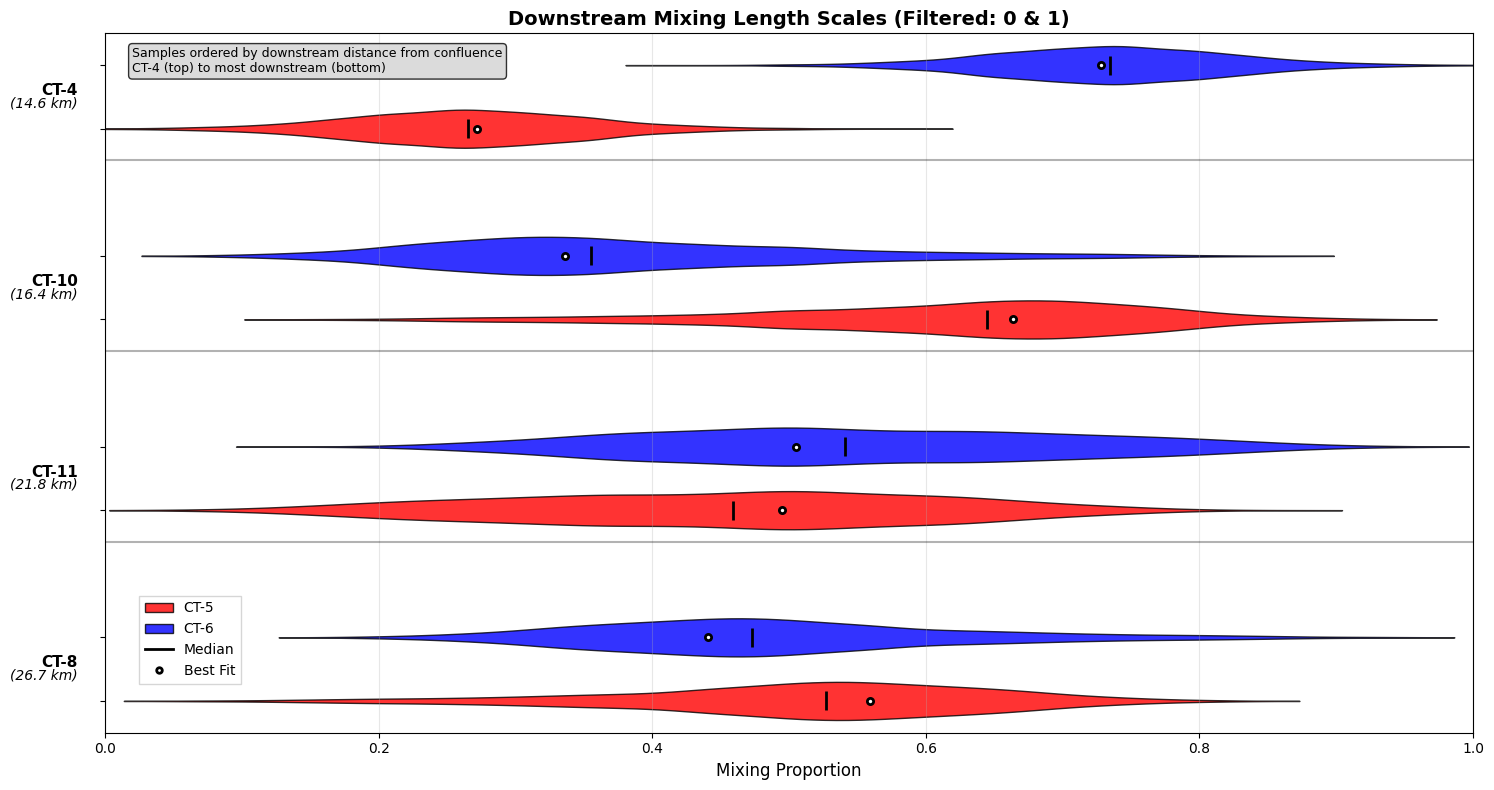

In [8]:
# Plot CT-5 and CT-6 mixing for samples at different downstream distances with filtering.    
# Define sample data in original order (will be sorted by distance later)
sample_names = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
csv_files = [
        '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-5_ct-6_to_ct-4.csv',
        '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-5_ct-6_to_ct-10.csv',
        '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-5_ct-6_to_ct-11.csv',
        '/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/Zircon/detritalPy_mix/Spreadsheets/mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv'
    ]
    
# Best-fit mixing proportions for each sample (corresponding to sample_names order)
best_fit_values = [
        [0.272, 0.728],  # CT-4: 27.2% CT-5, 72.8% CT-6
        [0.664, 0.336],  # CT-10: 66.4% CT-5, 33.6% CT-6
        [0.495, 0.505],  # CT-11: 49.5% CT-5, 50.5% CT-6
        [0.559, 0.441]   # CT-8: 55.9% CT-5, 44.1% CT-6
    ]
    
# Create plot with legend and filtering
fig, ax, filtered_data = plot_downstream_violin_filtered(
    csv_files=csv_files,
    sample_names=sample_names,
    df_coords=df,
    best_fit_values_list=best_fit_values,
    labels=['CT-5', 'CT-6'],  # Component labels for legend
    colors=['red', 'blue'],   # Colors for CT-5 and CT-6 respectively
    #title='CT-5 + CT-6 Mixing: Downstream Length Scales',
    save_path='Figures/downstream_mixing_length_scales_filtered.png',
    filter_zeros_ones=True,    # Filter out end-member dominated samples
    pre_calculated_distances=distances
    )
    
plt.show()

## Be-10 downstream mixing

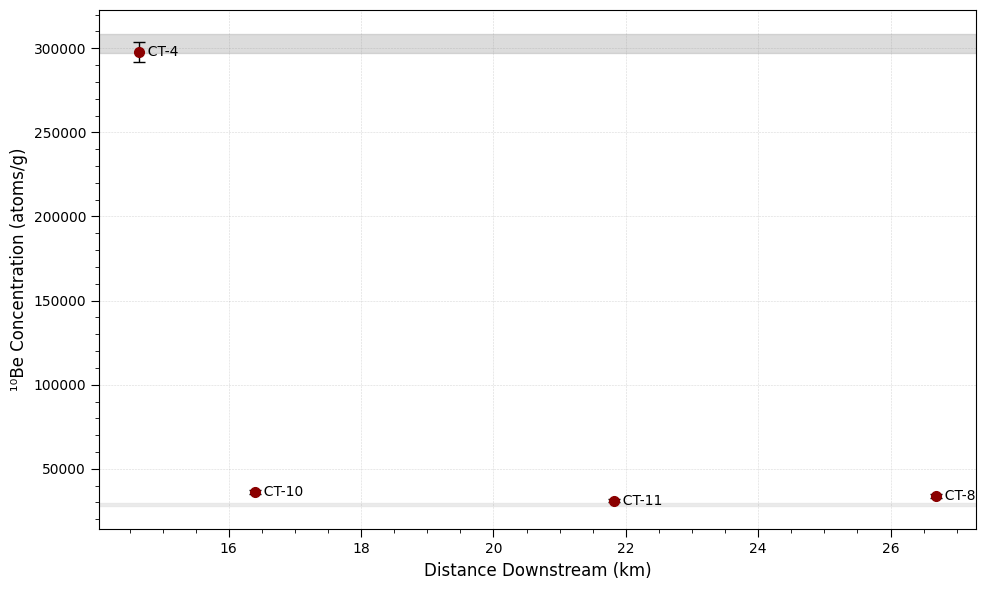

  sample   distance  be10_conc  be10_uncert
0   CT-4  14.646537   298000.0       5920.0
1  CT-10  16.399477    36400.0       1280.0
2  CT-11  21.821582    31100.0       1040.0
3   CT-8  26.685025    33800.0       1240.0


In [21]:
# Plotting the Be-10 vs distance downstream
# Only use downstream sequence samples
samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
# Load calculated distances
distances = distances
# Get data for plotting
plot_data = []
for sample in samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty and sample in distances:
        r = row.iloc[0]
        be10_conc = r['10Be_concentration']
        be10_uncert = r['10Be_concentration_uncertainty']
        
        if pd.notna(be10_conc):
            plot_data.append({
                'sample': r['Sample_ID'],
                'distance': distances[sample],
                'be10_conc': be10_conc,
                'be10_uncert': be10_uncert if pd.notna(be10_uncert) else 0
            })
# Convert to DataFrame and sort by distance
plot_df = pd.DataFrame(plot_data).sort_values('distance')

# Create plot 
fig, ax = plt.subplots(figsize=(10, 6))

# Extract data error bars
x_vals = plot_df['distance'].values
y_vals = plot_df['be10_conc'].values
y_err = plot_df['be10_uncert'].values

# Get CT-5 and CT-6 Be-10 concentrations for reference bars
ref_samples = ['CT-5', 'CT-6']
ref_data = {}
for sample in ref_samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty:
        r = row.iloc[0]
        if pd.notna(r['10Be_concentration']):
            ref_data[sample] = {
                'conc': r['10Be_concentration'],
                'uncert': r['10Be_concentration_uncertainty'] if pd.notna(r['10Be_concentration_uncertainty']) else 0
            }

# Add reference bands for CT-5 and CT-6
colors = {'CT-5': 'lightgray', 'CT-6': 'darkgray'}
for sample, data in ref_data.items():
    ax.axhspan(data['conc'] - data['uncert'], data['conc'] + data['uncert'],
               alpha=0.4, color=colors[sample], label=f"{sample}: {data['conc']:.2e} ± {data['uncert']:.2e}")

# Plot error bars
ax.errorbar(x_vals, y_vals, yerr=y_err, 
           fmt='o', markersize=7, capsize=4, capthick=1, 
           linewidth=1, color='darkred', ecolor='black', 
           markerfacecolor='darkred',
           zorder=3)

# Add sample labels
for _, row in plot_df.iterrows():
    ax.text(row['distance'], row['be10_conc'], f"  {row['sample']}", 
            verticalalignment='center', fontsize=10, zorder=4)

# Grid - only horizontal dashed lines for y-axis
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')

# Add minor ticks on both x and y axes
ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()

# Labels and title
ax.set_xlabel('Distance Downstream (km)', fontsize=12)
ax.set_ylabel('¹⁰Be Concentration (atoms/g)', fontsize=12)
#ax.set_title('¹⁰Be vs Distance Downstream', fontsize=14)

plt.tight_layout()
plt.savefig('Figures/downstream_mixing_Be-10.png')
plt.show()
print(plot_df[['sample', 'distance', 'be10_conc', 'be10_uncert']])

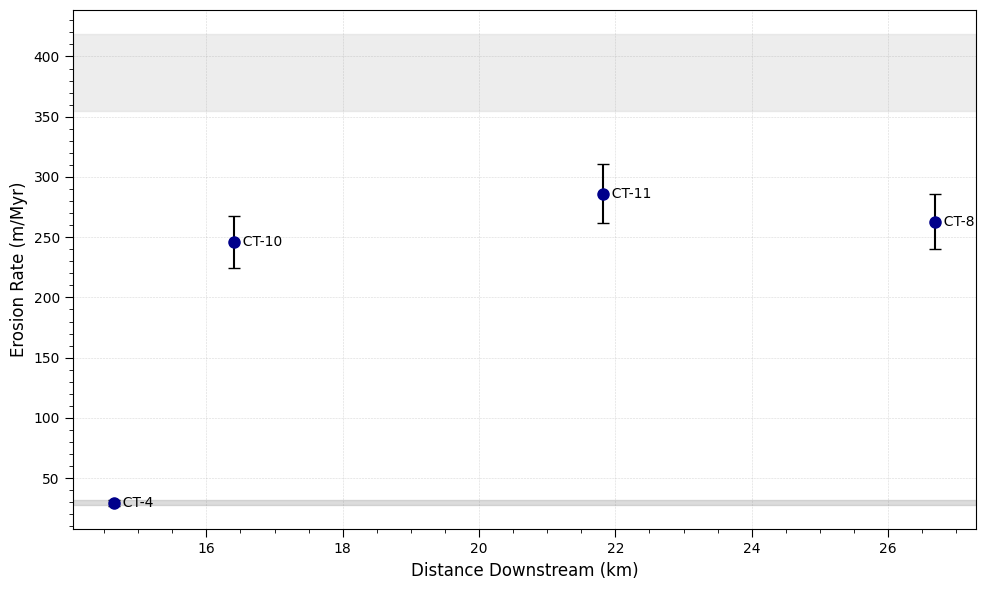

  sample   distance  erosion_rate  erosion_uncert
0   CT-4  14.646537          29.6            2.44
1  CT-10  16.399477         246.0           21.30
2  CT-11  21.821582         286.0           24.50
3   CT-8  26.685025         263.0           22.90


In [22]:
# Plotting the Erosion Rate vs distance downstream, using external uncertainty which accounts for all uncertainties
# Only use downstream sequence samples
samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
# Load calculated distances
distances = distances
# Get data for plotting
plot_data = []
for sample in samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty and sample in distances:
        r = row.iloc[0]
        erosion_rate = r['Erosion_rate']
        erosion_uncert = r['Erosion_rate_uncertainty_external']
        
        if pd.notna(erosion_rate):
            plot_data.append({
                'sample': r['Sample_ID'],
                'distance': distances[sample],
                'erosion_rate': erosion_rate,
                'erosion_uncert': erosion_uncert if pd.notna(erosion_uncert) else 0
            })
# Convert to DataFrame and sort by distance
plot_df = pd.DataFrame(plot_data).sort_values('distance')
# Create plot with improved formatting
fig, ax = plt.subplots(figsize=(10, 6))
# Extract data for error bars
x_vals = plot_df['distance'].values
y_vals = plot_df['erosion_rate'].values
y_err = plot_df['erosion_uncert'].values

# Get CT-5 and CT-6 erosion rates for reference bars
ref_samples = ['CT-5', 'CT-6']
ref_data = {}
for sample in ref_samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty:
        r = row.iloc[0]
        if pd.notna(r['Erosion_rate']):
            ref_data[sample] = {
                'rate': r['Erosion_rate'],
                'uncert': r['Erosion_rate_uncertainty_external'] if pd.notna(r['Erosion_rate_uncertainty_external']) else 0
            }

# Add reference bands for CT-5 and CT-6
colors = {'CT-5': 'lightgray', 'CT-6': 'darkgray'}
for sample, data in ref_data.items():
    ax.axhspan(data['rate'] - data['uncert'], data['rate'] + data['uncert'],
               alpha=0.4, color=colors[sample], label=f"{sample}: {data['rate']:.1f} ± {data['uncert']:.1f} m/Myr")

# Plot with error bars
ax.errorbar(x_vals, y_vals, yerr=y_err, 
           fmt='o', markersize=8, capsize=4, capthick=1, 
           linewidth=1.5, color='darkblue', ecolor='black', 
           markerfacecolor='darkblue',
           zorder=3)
# Add sample labels
for _, row in plot_df.iterrows():
    ax.text(row['distance'], row['erosion_rate'], f"  {row['sample']}", 
            verticalalignment='center', fontsize=10, zorder=4)
    
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')

# Add minor ticks on both x and y axes
ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()

# Labels and title
ax.set_xlabel('Distance Downstream (km)', fontsize=12)
ax.set_ylabel('Erosion Rate (m/Myr)', fontsize=12)
#ax.set_title('Erosion Rate vs Distance Downstream', fontsize=14)
plt.tight_layout()
plt.savefig('Figures/downstream_mixing_erosionrate.png')
plt.show()
print(plot_df[['sample', 'distance', 'erosion_rate', 'erosion_uncert']])

## Plotting all samples based on distance

#### Definitions for calculations and plotting

In [11]:
def calculate_stream_distances_from_outlet(samples_gdf, flowlines_gdf, 
                                          outlet_coords=(208913.7, 6126075.0)):
    """
    Calculate stream distances from the outlet point to all samples using flowlines.
    
    Parameters:
    - samples_gdf: GeoDataFrame with sample points
    - flowlines_gdf: GeoDataFrame with flowlines created from raster
    - outlet_coords: tuple of (x, y) coordinates for the outlet point
    
    Returns:
    - distances: dictionary with sample names as keys and distances in km as values
    - outlet_point: Point geometry of the outlet
    """
    
    from shapely.geometry import Point
    
    distances = {}
    outlet_point = Point(outlet_coords[0], outlet_coords[1])
    
    print(f"Using outlet coordinates: {outlet_coords}")
    
    # Calculate distance for each sample
    for sample_name in samples_gdf['Name'].unique():
        sample_flowline = flowlines_gdf[flowlines_gdf['sample_name'] == sample_name]
        
        if sample_flowline.empty:
            print(f"Warning: No flowline found for {sample_name}")
            continue
        
        line = sample_flowline.geometry.iloc[0]
        sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
        
        # Method 1: Try to project outlet onto the flowline
        projected_distance = line.project(outlet_point)
        point_on_line = line.interpolate(projected_distance)
        
        # Check if outlet is close to the flowline (within 500m tolerance)
        if outlet_point.distance(point_on_line) < 500:
            # Outlet is along this flowline - calculate distance from sample to outlet
            sample_distance_on_line = line.project(sample_point)
            
            # Distance from sample to outlet along the line
            if sample_distance_on_line < projected_distance:
                # Sample is upstream from outlet
                distance = (projected_distance - sample_distance_on_line) / 1000
            else:
                # Sample is downstream from outlet (shouldn't happen with proper outlet)
                distance = (sample_distance_on_line - projected_distance) / 1000
            
            distances[sample_name] = distance
            print(f"{sample_name}: {distance:.2f} km from outlet (along flowline)")
            
        else:
            # Method 2: Use end point of flowline as approximation
            line_end = Point(line.coords[-1])  # Last point of the flowline
            
            # Distance from sample (start of flowline) to outlet
            # This assumes the flowline flows towards the outlet
            flowline_length = line.length / 1000  # Convert to km
            end_to_outlet_distance = line_end.distance(outlet_point) / 1000
            
            # Total distance is flowline length plus distance from end to outlet
            total_distance = flowline_length + end_to_outlet_distance
            
            distances[sample_name] = total_distance
            print(f"{sample_name}: {total_distance:.2f} km from outlet (flowline + direct)")
    
    return distances, outlet_point

# Example usage function
def run_outlet_distance_analysis():
    """
    Run the complete analysis calculating distances from outlet
    """
    import geopandas as gpd
    
    # File paths (same as your original code)
    flow_direction_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/fd_utm30m"
    area_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/area_utm30m"
    samples_path = "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/mataquitosamplepoints_corrected_for_flow_30mDEM.shp"
    
    # Load sample points
    samples_gdf = gpd.read_file(samples_path)
    
    # Generate flowlines (using the function from your original code)
    flowlines_gdf = create_flowlines_from_raster(
        flow_direction_path, 
        area_path, 
        samples_gdf,
        min_drainage_area=50
    )
    
    print(f"Generated {len(flowlines_gdf)} flowlines")
    
    # Calculate distances from outlet
    outlet_distances, outlet_point = calculate_stream_distances_from_outlet(
        samples_gdf, 
        flowlines_gdf,
        outlet_coords=(208913.7, 6126075.0)
    )
    
    return outlet_distances, outlet_point

In [12]:
def create_visualization_with_outlet_distances(samples_gdf, flowlines_gdf, distances, outlet_point):
    """
    Create a visualization showing the stream network with distances from outlet.
    """
    import matplotlib.pyplot as plt
    import geopandas as gpd
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot flowlines FIRST with explicit low zorder (background layer)
    flowlines_gdf.plot(ax=ax, color='blue', linewidth=2, alpha=0.7, label='Generated Flowlines', zorder=1)
    
    # Plot sample points with high zorder (on top of flowlines)
    samples_gdf.plot(ax=ax, color='red', markersize=100, alpha=0.8, label='Sample Points', zorder=10)
    
    # Plot outlet point with high zorder (on top of flowlines)
    if outlet_point:
        outlet_gdf = gpd.GeoDataFrame([{'geometry': outlet_point}], crs=samples_gdf.crs)
        outlet_gdf.plot(ax=ax, color='green', markersize=50, marker='s', 
                       label='River Outlet', alpha=0.9, linewidth=2, zorder=10)
    
    # Add sample labels with highest zorder (on top of everything)
    for idx, sample in samples_gdf.iterrows():
        ax.annotate(sample['Name'], 
                   xy=(sample.geometry.x, sample.geometry.y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold', zorder=20)
    
    # Add distance labels with highest zorder (on top of everything)
    for sample_name in distances.keys():
        if sample_name in samples_gdf['Name'].values:
            sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
            distance = distances[sample_name]
            
            label = f"{distance:.1f} km from outlet"
            
            ax.annotate(label, 
                       xy=(sample_point.x, sample_point.y),
                       xytext=(10, -15), textcoords='offset points',
                       fontsize=8, 
                       bbox=dict(boxstyle="round,pad=0.1", facecolor="lightyellow", alpha=0.6),
                       zorder=20)
    
    # Set labels and title
    ax.set_xlabel('Easting (UTM)')
    ax.set_ylabel('Northing (UTM)')
    ax.set_title('Stream Network: Mataquito River Watershed - Distances from Outlet')
    ax.legend()
    
    # Grid and formatting
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('Figures/outlet_distances_visualization.png', dpi=300, bbox_inches='tight')
    
    return fig, ax

### Distances from outlet

Generated 11 flowlines
Using outlet coordinates: (208913.7, 6126075.0)
CT-9: 18.50 km from outlet (along flowline)
CT-2: 23.44 km from outlet (along flowline)
CT-3: 40.53 km from outlet (along flowline)
CT-8: 84.83 km from outlet (along flowline)
CT-11: 92.01 km from outlet (along flowline)
CT-10: 99.47 km from outlet (along flowline)
CT-4: 106.76 km from outlet (along flowline)
CT-5: 125.32 km from outlet (along flowline)
CT-6: 127.36 km from outlet (along flowline)
CT-1: 183.05 km from outlet (along flowline)
CT-7: 198.48 km from outlet (along flowline)


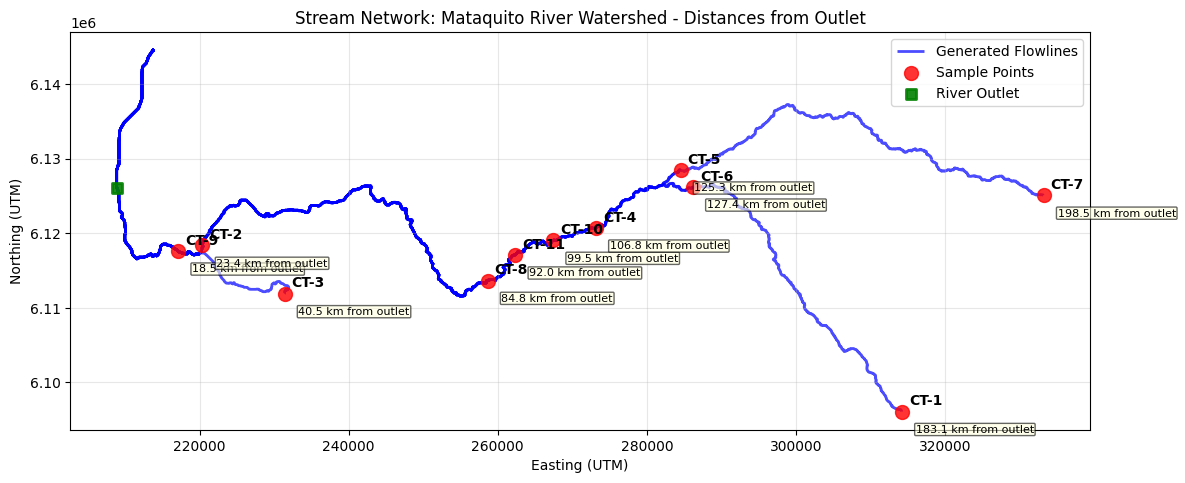

In [13]:
# Run the outlet distance analysis
outlet_distances, outlet_point = run_outlet_distance_analysis()

# Load the data (if not already loaded)
samples_gdf = gpd.read_file("/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/mataquitosamplepoints_corrected_for_flow_30mDEM.shp")

# Create flowlines (if not already created)
flowlines_gdf = create_flowlines_from_raster(
    "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/fd_utm30m", 
    "/Users/Glong1/Desktop/Andes/AndesTG/Mataquito/area_utm30m", 
    samples_gdf,
    min_drainage_area=50
)

# Create visualization
fig, ax = create_visualization_with_outlet_distances(
    samples_gdf, flowlines_gdf, outlet_distances, outlet_point
)
plt.show()

In [14]:
def plot_all_samples_from_outlet(df, distances):
    """
    Plot all CT samples using distances from outlet point
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Use all CT samples instead of just the subset
    samples = [f'CT-{i}' for i in range(1, 12)]
    
    # Use calculated distances
    distances = distances
    
    # Get data for plotting (same as original code)
    plot_data = []
    for sample in samples:
        row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
        if not row.empty and sample in distances:
            r = row.iloc[0]
            erosion_rate = r['Erosion_rate']
            erosion_uncert = r['Erosion_rate_uncertainty_external']
            
            if pd.notna(erosion_rate):
                plot_data.append({
                    'sample': r['Sample_ID'],
                    'distance': distances[sample],
                    'erosion_rate': erosion_rate,
                    'erosion_uncert': erosion_uncert if pd.notna(erosion_uncert) else 0
                })
    
    # Convert to DataFrame and sort by distance
    plot_df = pd.DataFrame(plot_data).sort_values('distance')
    
    # Create plot with improved formatting (original style)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract data for proper error bars
    x_vals = plot_df['distance'].values
    y_vals = plot_df['erosion_rate'].values
    y_err = plot_df['erosion_uncert'].values
    
    # Plot with proper error bars
    ax.errorbar(x_vals, y_vals, yerr=y_err, 
               fmt='o', markersize=8, capsize=4, capthick=1, 
               linewidth=1.5, color='darkblue', ecolor='black', 
               markerfacecolor='darkblue',
               zorder=3)
    
    # Add sample labels
    for _, row in plot_df.iterrows():
        ax.text(row['distance'], row['erosion_rate'], f"  {row['sample']}", 
                verticalalignment='center', fontsize=10, zorder=4)
        
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')
    
    # Add minor ticks on both x and y axes
    ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', length=3)
    ax.minorticks_on()
    
    # Labels and title
    ax.set_xlabel('Distance from Outlet (km)', fontsize=12)
    ax.set_ylabel('Erosion Rate (m/Myr)', fontsize=12)
    # ax.set_title('Erosion Rate vs Distance from Outlet', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('Figures/downstream_mixing_erosionrate_from_outlet.png')
    plt.show()
    print(plot_df[['sample', 'distance', 'erosion_rate', 'erosion_uncert']])
    
    return plot_df

In [15]:
def plot_be10_concentration_from_outlet(df, distances):
    """
    Plot Be-10 concentration for all CT samples using distances from outlet point
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    
    # Use all CT samples instead of just the subset
    samples = [f'CT-{i}' for i in range(1, 12)]
    
    # Use calculated distances
    distances = distances
    
    # Get data for plotting (same as original code)
    plot_data = []
    for sample in samples:
        row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
        if not row.empty and sample in distances:
            r = row.iloc[0]
            be10_conc = r['10Be_concentration']
            be10_uncert = r['10Be_concentration_uncertainty']
            
            if pd.notna(be10_conc):
                plot_data.append({
                    'sample': r['Sample_ID'],
                    'distance': distances[sample],
                    'be10_conc': be10_conc,
                    'be10_uncert': be10_uncert if pd.notna(be10_uncert) else 0
                })
    
    # Convert to DataFrame and sort by distance
    plot_df = pd.DataFrame(plot_data).sort_values('distance')
    
    # Create plot with improved formatting (original style)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract data for proper error bars
    x_vals = plot_df['distance'].values
    y_vals = plot_df['be10_conc'].values
    y_err = plot_df['be10_uncert'].values
    
    # Plot with proper error bars
    ax.errorbar(x_vals, y_vals, yerr=y_err, 
               fmt='o', markersize=8, capsize=4, capthick=1, 
               linewidth=1.5, color='darkred', ecolor='black', 
               markerfacecolor='darkred',
               zorder=3)
    
    # Add sample labels
    for _, row in plot_df.iterrows():
        ax.text(row['distance'], row['be10_conc'], f"  {row['sample']}", 
                verticalalignment='center', fontsize=10, zorder=4)
        
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')
    
    # Add minor ticks on both x and y axes
    ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', length=3)
    ax.minorticks_on()
    
    # Labels and title
    ax.set_xlabel('Distance from Outlet (km)', fontsize=12)
    ax.set_ylabel('¹⁰Be Concentration (atoms/g)', fontsize=12)
    # ax.set_title('¹⁰Be Concentration vs Distance from Outlet', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('Figures/downstream_mixing_be10concentration_from_outlet.png')
    plt.show()
    print(plot_df[['sample', 'distance', 'be10_conc', 'be10_uncert']])
    
    return plot_df

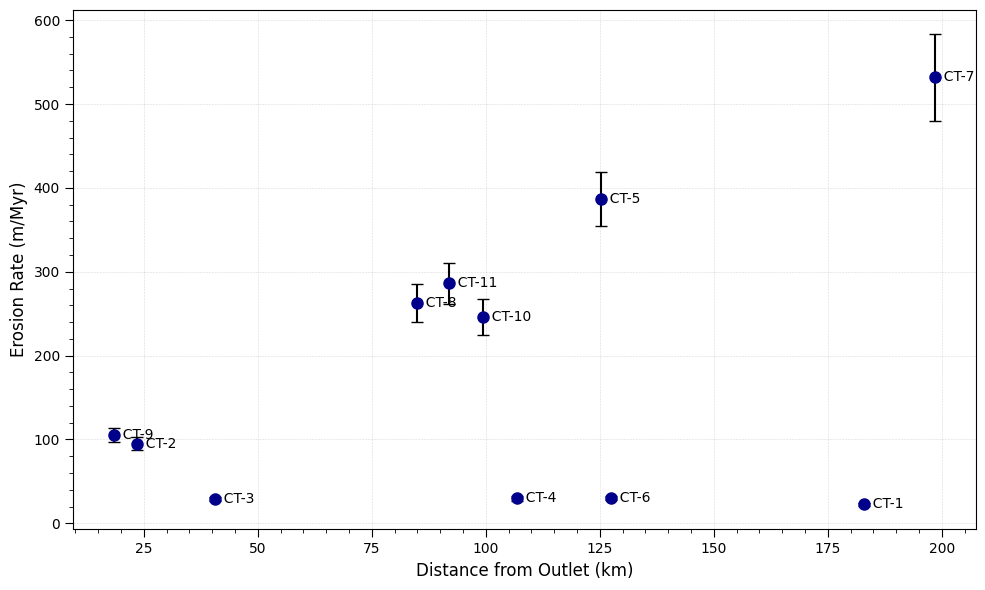

   sample    distance  erosion_rate  erosion_uncert
8    CT-9   18.499550         105.0            8.55
1    CT-2   23.440270          94.8            7.73
2    CT-3   40.525566          29.5            2.42
7    CT-8   84.828881         263.0           22.90
10  CT-11   92.014328         286.0           24.50
9   CT-10   99.473719         246.0           21.30
3    CT-4  106.755373          29.6            2.44
4    CT-5  125.321861         387.0           32.00
5    CT-6  127.363514          29.8            2.44
0    CT-1  183.050998          22.9            1.86
6    CT-7  198.483296         532.0           52.00


In [16]:
#Plot erosion rates vs distance from outlet using your Excel data
plot_df = plot_all_samples_from_outlet(df, outlet_distances)

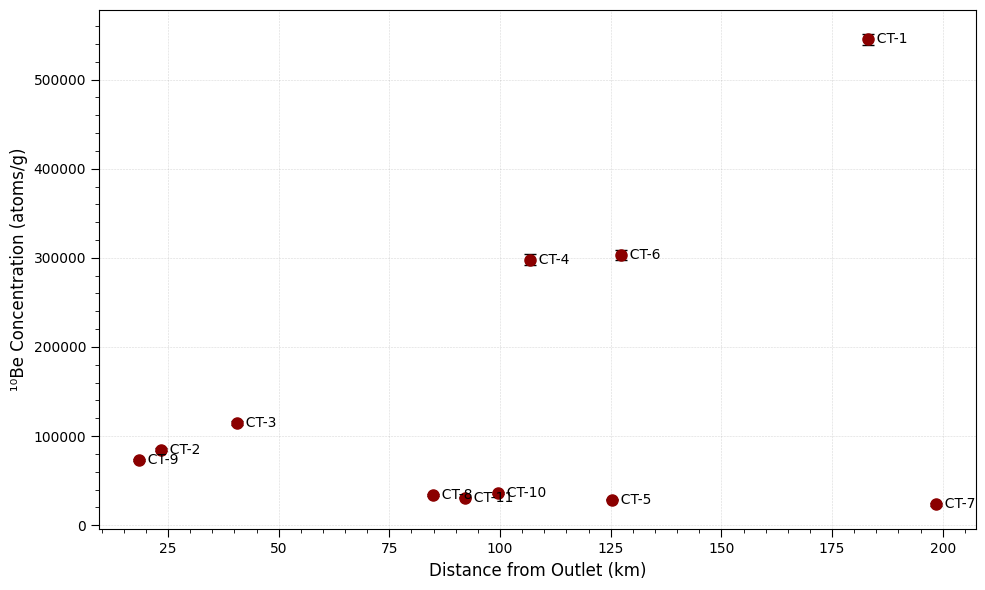

   sample    distance  be10_conc  be10_uncert
8    CT-9   18.499550    73400.0       1400.0
1    CT-2   23.440270    84600.0       1610.0
2    CT-3   40.525566   115000.0       2150.0
7    CT-8   84.828881    33800.0       1240.0
10  CT-11   92.014328    31100.0       1040.0
9   CT-10   99.473719    36400.0       1280.0
3    CT-4  106.755373   298000.0       5920.0
4    CT-5  125.321861    28800.0        686.0
5    CT-6  127.363514   303000.0       5700.0
0    CT-1  183.050998   545000.0       6580.0
6    CT-7  198.483296    23300.0       1340.0


In [17]:
# Plot Be-10 concentration vs distance from outlet
be10_plot_df = plot_be10_concentration_from_outlet(df, outlet_distances)